# Fitting to survival data with the multinomial likelihood

This notebook demonstrates how we can re-run a fit with a different loss configuration 
by estimating GUTS-SD parameters via sum of squares and multinomial likelihood, respectively.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from mempyfit import *

## Fit with sum of squares

Here we perform a fit to survival data with the default configurations, which uses 
the sum of squares as error model.

Fitted model using Nelder-Mead method.

#### ---- Estimated parameters ---- ####

{'h_b': np.float64(0.0034122582145570393),
 'k_d': np.float64(0.056506447952323346),
 'b': np.float64(0.0008101947870689963),
 'z': np.float64(430.4843067570853)}

### ---- Visual check ---- ####


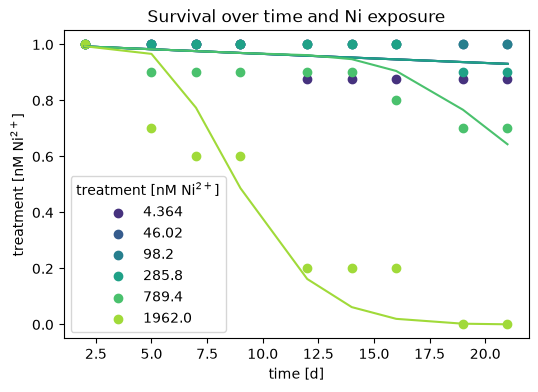

In [3]:
from survival.fitting_problem import prob
sol = prob.solve()
rep_ssq = sol.report()

In [4]:
sol.opt_result

       message: Maximum number of function evaluations has been exceeded.
       success: False
        status: 1
           fun: 0.2818733918512881
             x: [ 3.412e-03  5.651e-02  8.102e-04  4.305e+02]
           nit: 469
          nfev: 800
 final_simplex: (array([[ 3.412e-03,  5.651e-02,  8.102e-04,  4.305e+02],
                       [ 3.413e-03,  5.651e-02,  8.102e-04,  4.305e+02],
                       ...,
                       [ 3.413e-03,  5.651e-02,  8.102e-04,  4.305e+02],
                       [ 3.412e-03,  5.651e-02,  8.102e-04,  4.305e+02]],
                      shape=(5, 4)), array([ 2.819e-01,  2.819e-01,  2.819e-01,  2.819e-01,
                        2.819e-01]))

## Fit with multinomial likelihood

Now we do the same with the negative log-multinomial likelihood (defined as `nll_multinomial` in mempyfit). 

We can recycle the previously defined `FittingProblem` and re-assign the list of error models.
For this to work correctly, it is essential that `prob.define_loss()` is called after we have re-assigned the error models. (Doing so is technically redundant here because it is also done in `prob.solve()`).

Fitted model using Nelder-Mead method.

#### ---- Estimated parameters ---- ####

{'h_b': np.float64(0.003507532364607672),
 'k_d': np.float64(0.05571674957164202),
 'b': np.float64(0.0008301568731043096),
 'z': np.float64(419.34109344837026)}

### ---- Visual check ---- ####


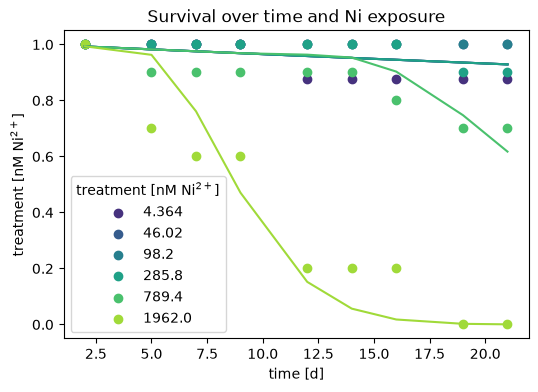

In [ ]:
import mempyfit

prob.data.error_models = [mempyfit.nll_multinomial]
prob.define_loss() 
sol = prob.solve()
rep_mll = sol.report()

Comparison of the parameter estimates. 
These should be quite similar, but identical. 
Note that we expect a larger difference for the confidence intervals.

In [7]:
rep_ssq['estimates'].update({'fit': 'ssq'})
rep_mll['estimates'].update({'fit': 'mll'})

pd.concat(
   [ pd.DataFrame(rep_ssq['estimates'], index = [1]),
    pd.DataFrame(rep_mll['estimates'], index = [2])]
)

,h_b,k_d,b,z,fit
1,0.003412,0.056506,0.00081,430.484307,ssq
2,0.003508,0.055717,0.00083,419.341093,mll


In [8]:
sol.opt_result

       message: Maximum number of function evaluations has been exceeded.
       success: False
        status: 1
           fun: 5.0922385033294075
             x: [ 3.508e-03  5.572e-02  8.302e-04  4.193e+02]
           nit: 445
          nfev: 800
 final_simplex: (array([[ 3.508e-03,  5.572e-02,  8.302e-04,  4.193e+02],
                       [ 3.508e-03,  5.572e-02,  8.302e-04,  4.193e+02],
                       ...,
                       [ 3.508e-03,  5.572e-02,  8.302e-04,  4.193e+02],
                       [ 3.508e-03,  5.572e-02,  8.302e-04,  4.193e+02]],
                      shape=(5, 4)), array([ 5.092e+00,  5.092e+00,  5.092e+00,  5.092e+00,
                        5.092e+00]))